In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
print("Libraries imported Successfully")

Libraries imported Successfully


In [3]:
df = pd.read_csv(r'C:\Users\PC\Desktop\News_Sentiment\data\raw\NewsData\raw_analyst_ratings.csv')
df.head(2)

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A


Headline Length Statistics


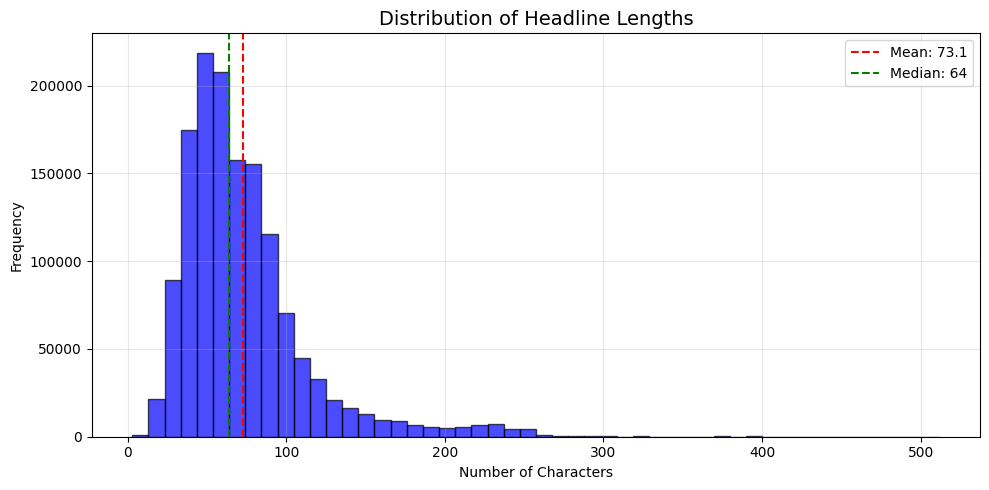

In [4]:
# Calculate headline lengths
df['headline_length']=df['headline'].str.len()
# Statistics

print("Headline Length Statistics")

df['headline_length'].describe()

# # Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['headline_length'], bins=50, color='blue', alpha=0.7, edgecolor='black')
ax.axvline(df['headline_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['headline_length'].mean():.1f}")
ax.axvline(df['headline_length'].median(), color='green', linestyle='--', label=f"Median: {df['headline_length'].median():.0f}")
ax.set_title('Distribution of Headline Lengths', fontsize=14)
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#count articles per publisher to ideentify which sources are the most active
publisher_count = df['publisher'].value_counts()
print("Top 10 Publishers by Article Count:")
print(publisher_count.head(10))

Top 10 Publishers by Article Count:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


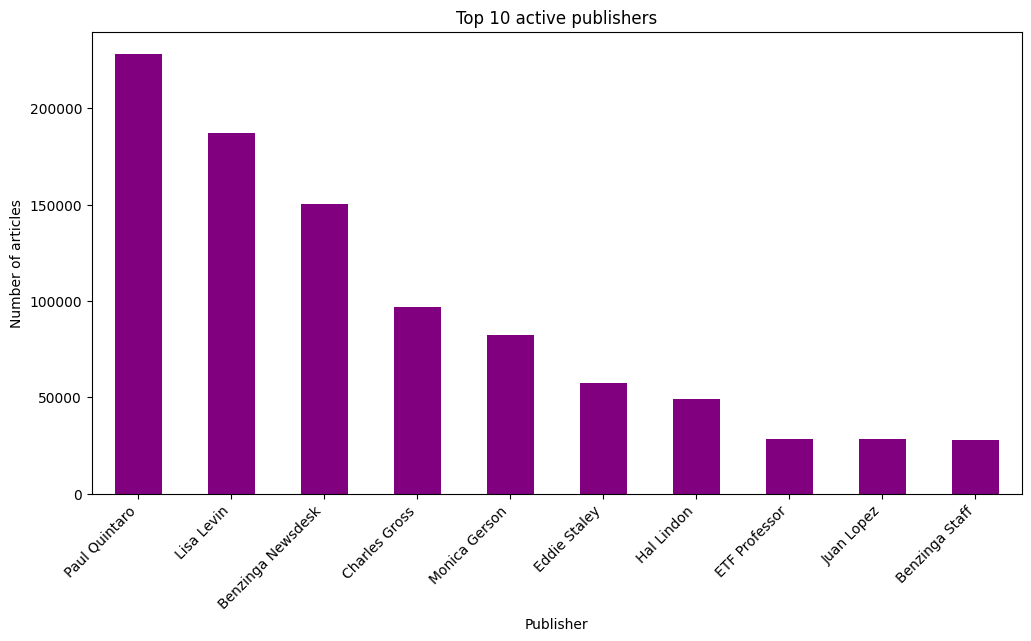

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
publisher_count.head(10).plot(kind='bar',ax=ax,color='purple')
ax.set_title('Top 10 active publishers')
ax.set_xlabel('Publisher')
ax.set_ylabel('Number of articles')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

In [22]:
#publication dates trend
df['date'] = pd.to_datetime(df['date'],utc=True,format='mixed')

In [19]:
print(df['date'].unique()[:5])

<StringArray>
['2020-06-05 10:30:54-04:00', '2020-06-03 10:45:20-04:00',
 '2020-05-26 04:30:07-04:00', '2020-05-22 12:45:06-04:00',
 '2020-05-22 11:38:59-04:00']
Length: 5, dtype: str


In [24]:
df['Year']=df['date'].dt.year
df['Month']=df['date'].dt.month
df['Day']=df['date'].dt.day
df.head(2)

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,Year,Month,Day
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,39,2020,6,5
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,42,2020,6,3


In [28]:
#Articles per day
daily_counts = df.groupby(df['date'].dt.date).size()
print(daily_counts.head(5))

date
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64


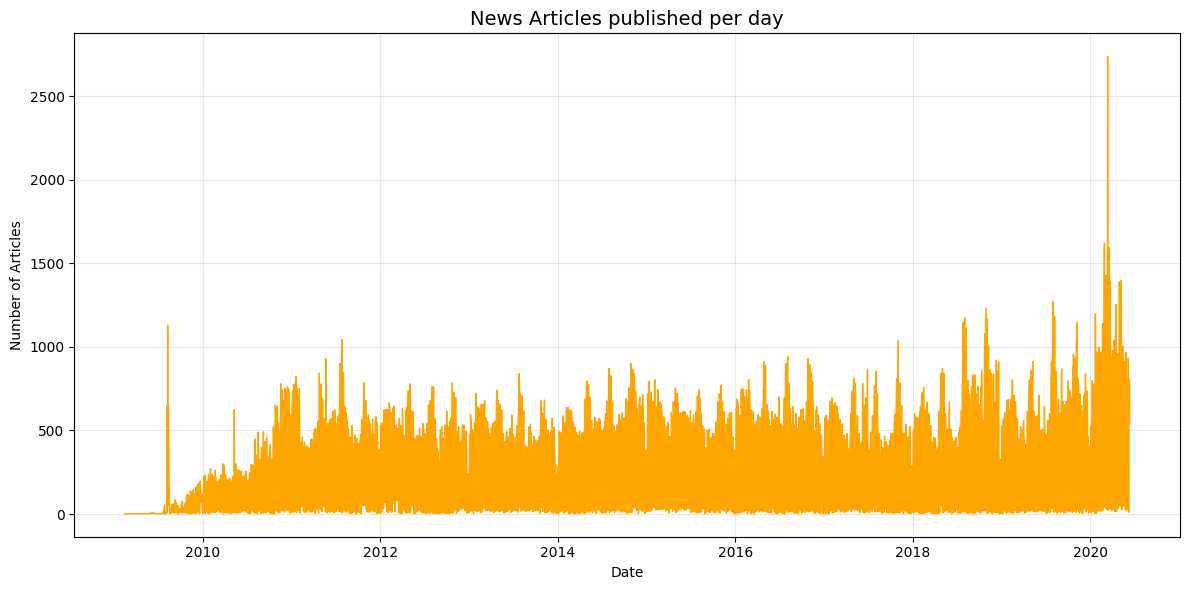

In [30]:
fig,ax=plt.subplots(figsize=(12,6))
ax.plot(daily_counts.index,daily_counts.values,color='orange',linewidth=1)
ax.set_title('News Articles published per day',fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Articles')
ax.grid(True,alpha=0.3)
plt.tight_layout()  
plt.show()

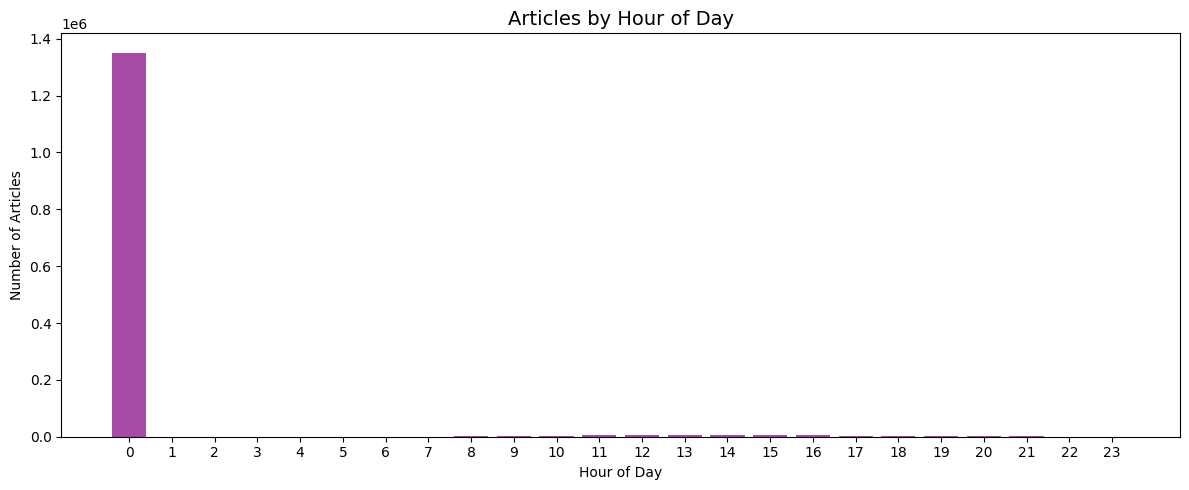

Peak publishing hour: 0:00


In [46]:
df['hour'] = df['date'].dt.hour
hourly_counts = df['hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_counts.index, hourly_counts.values, color='purple', alpha=0.7)
ax.set_title('Articles by Hour of Day', fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Articles')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(f"Peak publishing hour: {hourly_counts.idxmax()}:00")

In [38]:
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r'[^a-zA-Z\s]','',text)
    return text
df['clean_headline']=df['headline'].apply(clean_text)
 
#finding common keywords in headline by using countVectorizer

vectorizer = CountVectorizer(max_features=20,stop_words='english')
X=vectorizer.fit_transform(df['clean_headline']) #fit_transform is a class of countVectorization that takes a document as an argument and returns a matrix of token counts
#and x is a matrix ha contain counts
print(X)
keywords = vectorizer.get_feature_names_out()
keyword_counts = X.toarray().sum(axis=0)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1668432 stored elements and shape (1407328, 20)>
  Coords	Values
  (0, 14)	1
  (0, 19)	1
  (1, 14)	1
  (1, 19)	1
  (3, 14)	1
  (4, 10)	1
  (4, 8)	1
  (5, 8)	1
  (6, 10)	1
  (6, 8)	1
  (7, 13)	1
  (7, 15)	1
  (7, 5)	1
  (7, 12)	1
  (8, 10)	1
  (8, 8)	1
  (9, 8)	1
  (10, 14)	1
  (11, 10)	1
  (11, 8)	1
  (12, 14)	1
  (13, 13)	1
  (13, 15)	1
  (13, 5)	1
  (13, 12)	1
  :	:
  (1407303, 14)	1
  (1407304, 5)	1
  (1407304, 11)	1
  (1407305, 5)	1
  (1407305, 11)	1
  (1407309, 0)	1
  (1407310, 14)	1
  (1407310, 19)	1
  (1407311, 13)	1
  (1407313, 5)	1
  (1407313, 11)	1
  (1407313, 18)	1
  (1407313, 6)	1
  (1407314, 4)	1
  (1407316, 15)	1
  (1407316, 7)	1
  (1407318, 4)	1
  (1407319, 14)	1
  (1407320, 13)	1
  (1407320, 7)	1
  (1407320, 0)	1
  (1407325, 16)	1
  (1407326, 9)	1
  (1407327, 8)	1
  (1407327, 15)	1


In [41]:
keywords_df = pd.DataFrame({'keyword':keywords,'count':keyword_counts})
keywords_df = keywords_df.sort_values('count', ascending=False)

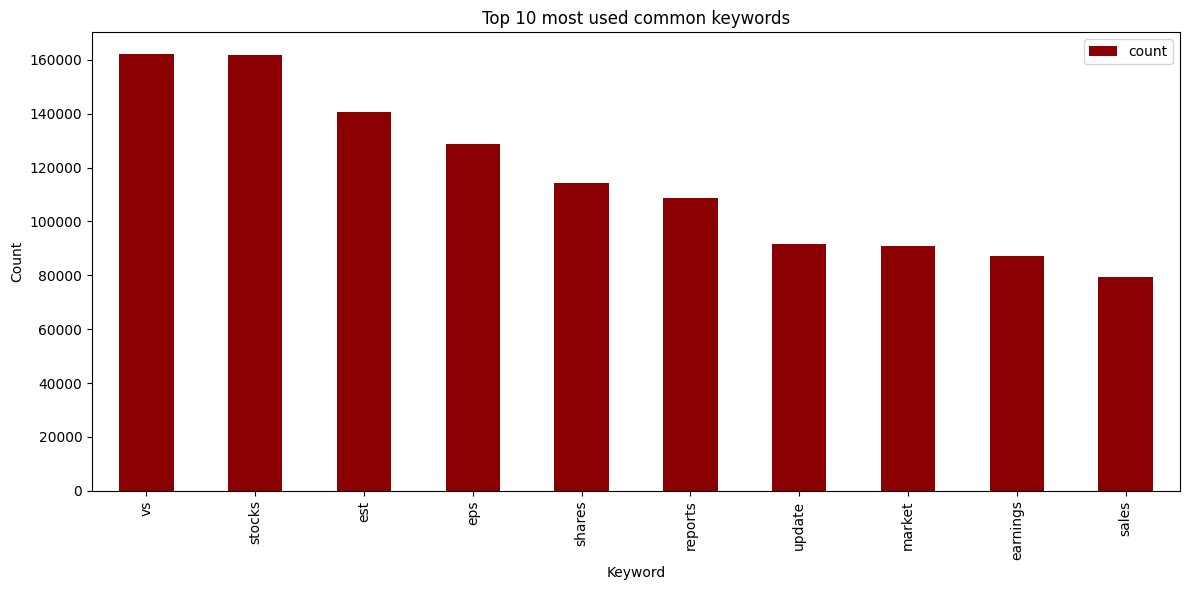

In [45]:
fig,ax = plt.subplots(figsize=(12,6))
keywords_df.head(10).plot(kind='bar', x='keyword', y='count', ax=ax, color='darkred')
ax.set_title('Top 10 most used common keywords')
ax.set_xlabel('Keyword')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Top 15 Most Common 2-Word Phrases
                phrase   count
14              vs est  129339
4               eps vs   70250
10         reports eps   51208
8         price target   47266
12       stocks moving   40072
6        market update   33089
3   earnings scheduled   32055
5   initiates coverage   28980
9            raises pt   27242
2    companies trading   23170
13      trading higher   22939
0              adj eps   21708
7    premarket session   21670
11            sales vs   21629
1   benzingas upgrades   21115


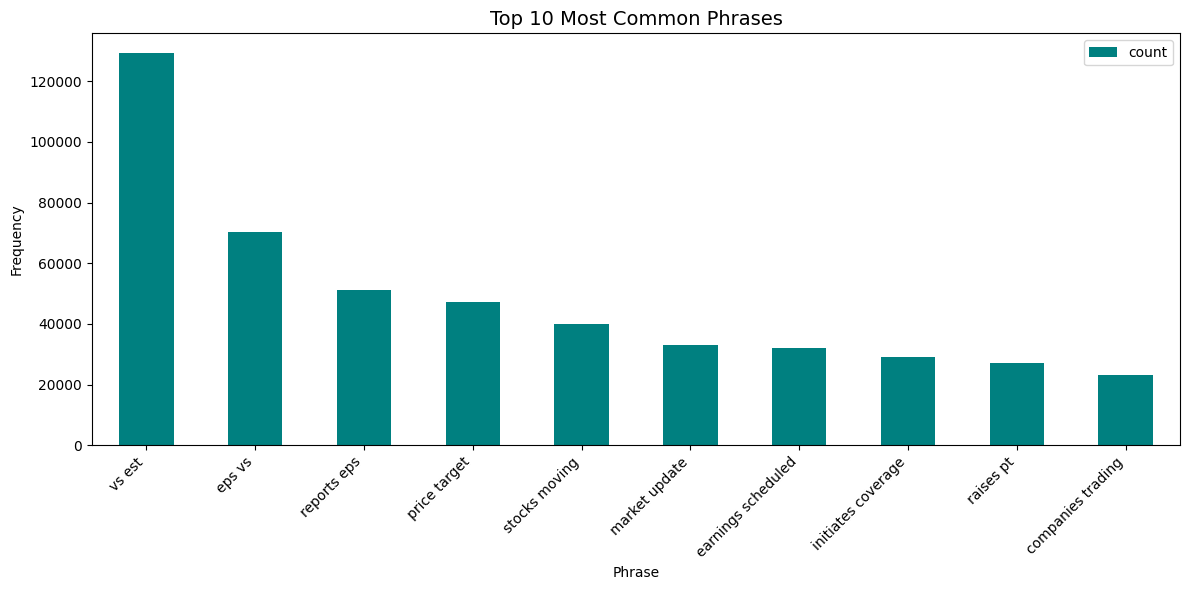

In [ ]:
vectorizer_bigram = CountVectorizer(ngram_range=(2,2), max_features=15, stop_words='english')
X_bigram = vectorizer_bigram.fit_transform(df['clean_headline'])

phrases = vectorizer_bigram.get_feature_names_out()
phrase_counts = X_bigram.toarray().sum(axis=0)

phrases_df = pd.DataFrame({'phrase': phrases, 'count': phrase_counts})
phrases_df = phrases_df.sort_values('count', ascending=False)

print("Top 15 Most Common 2-Word Phrases")
print(phrases_df)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
phrases_df.head(10).plot(kind='bar', x='phrase', y='count', ax=ax, color='teal')
ax.set_title('Top 10 Most Common Phrases', fontsize=14)
ax.set_xlabel('Phrase')
ax.set_ylabel('Frequency')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 15 Publishers/Domains
domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64


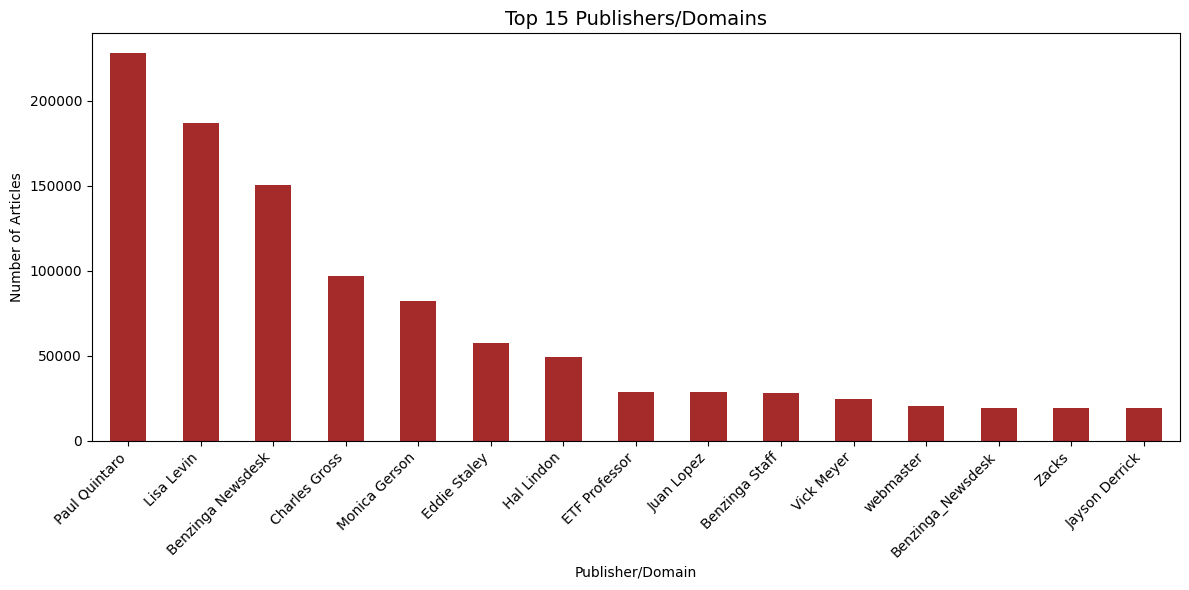

In [ ]:
# Extract domain if email address
df['domain'] = df['publisher'].apply(lambda x: x.split('@')[1] if '@' in str(x) else x)
domain_counts = df['domain'].value_counts().head(15)

print("Top 15 Publishers/Domains")
print(domain_counts)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
domain_counts.plot(kind='bar', ax=ax, color='brown')
ax.set_title('Top 15 Publishers/Domains', fontsize=14)
ax.set_xlabel('Publisher/Domain')
ax.set_ylabel('Number of Articles')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()